# Cross-validation comparison: RF_TabPFN, with_HPO, and without_HPO

This notebook compares the three methods across the target properties using normalized RMSE and R2. Because the targets use different units, NRMSE is computed as `CV_RMSE / target_range`, where `target_range = max(actual) - min(actual)` for that target pooled across the prediction CSVs from all three methods.


In [1]:
from pathlib import Path
import csv
import json
import math
import sys

try:
    from IPython.display import Image as DisplayImage, Markdown, display
except Exception:
    DisplayImage = None
    Markdown = str
    display = print

ROOT = Path.cwd()
if not (ROOT / "RF_TabPFN").exists():
    ROOT = Path("/home/draju/A6/TabPFN").resolve()

OUT = ROOT / "comparisonCV_outputs"
OUT.mkdir(exist_ok=True)

# ── thermoift path ──────────────────────────────────────────────────────────
for _candidate in [
    Path("/home/draju/A6/PCSAFT_cDFT/thermoift/src"),
    Path("/home/darshan/A6/PCSAFT_cDFT/thermoift/src"),
]:
    if _candidate.exists() and str(_candidate) not in sys.path:
        sys.path.insert(0, str(_candidate))
        break

METHODS    = ["without_HPO", "with_HPO", "RF_TabPFN"]
PROPERTIES = ["P_bubble", "P_dew", "gamma", "interfacial_thickness"]
DISPLAY_LABELS = {
    "P_bubble":              "P_bubble",
    "P_dew":                 "P_dew",
    "gamma":                 "gamma",
    "interfacial_thickness": "thickness",
}

# ── per-property colours ────────────────────────────────────────────────────
TARGET_COLORS = {
    "gamma":                 {"facecolor": "lightgreen", "edgecolor": "darkgreen"},
    "delta_gamma":           {"facecolor": "lightgreen", "edgecolor": "darkgreen"},
    "interfacial_thickness": {"facecolor": "#FDB863",    "edgecolor": "#B35806"},
    "p_dew":                 {"facecolor": "#FF6B6B",    "edgecolor": "darkred"},
    "p_bubble":              {"facecolor": "lightblue",  "edgecolor": "darkblue"},
}
PROP_COLOR_KEY = {
    "P_bubble":              "p_bubble",
    "P_dew":                 "p_dew",
    "gamma":                 "gamma",
    "interfacial_thickness": "interfacial_thickness",
}

# ── hatch patterns distinguish methods ─────────────────────────────────────
HATCH_PATTERNS = {
    "without_HPO": "",
    "with_HPO":    "///",
    "RF_TabPFN":   "xxx",
}
METHOD_DISPLAY = {
    "without_HPO": r"$\mathrm{without\ HPO}$",
    "with_HPO":    r"$\mathrm{with\ HPO}$",
    "RF_TabPFN":   r"$\mathrm{RF{+}TabPFN}$",
}

METRIC_FILES = {
    "without_HPO": {
        "P_bubble":              "without_HPO/TabPFN_P_bubble_OUTPUTS/TabPFN_P_bubble_metrics.json",
        "P_dew":                 "without_HPO/TabPFN_P_dew_OUTPUTS/TabPFN_P_dew_metrics.json",
        "gamma":                 "without_HPO/TabPFN_gamma_OUTPUTS/TabPFN_gamma_metrics.json",
        "interfacial_thickness": "without_HPO/TabPFN_interfacial_thickness_OUTPUTS/TabPFN_interfacial_thickness_metrics.json",
    },
    "with_HPO": {
        "P_bubble":              "with_HPO/SLURMBubble/TabPFN_P_bubble_metrics.json",
        "P_dew":                 "with_HPO/SLURMDew/TabPFN_P_dew_metrics.json",
        "gamma":                 "with_HPO/SLURMGamma/TabPFN_gamma_metrics.json",
        "interfacial_thickness": "with_HPO/SLURMTHICKNESS/TabPFN_interfacial_thickness_metrics.json",
    },
    "RF_TabPFN": {
        "P_bubble":              "RF_TabPFN/SLURMBubble/RF_TabPFN_P_bubble_metrics.json",
        "P_dew":                 "RF_TabPFN/SLURMDew/RF_TabPFN_P_dew_metrics.json",
        "gamma":                 "RF_TabPFN/SLURMGamma/RF_TabPFN_gamma_metrics.json",
        "interfacial_thickness": "RF_TabPFN/SLURMTHICKNESS/RF_TabPFN_interfacial_thickness_metrics.json",
    },
}
PREDICTION_FILES = {
    "without_HPO": {
        "P_bubble":              "without_HPO/TabPFN_P_bubble_OUTPUTS/TabPFN_P_bubble_predictions.csv",
        "P_dew":                 "without_HPO/TabPFN_P_dew_OUTPUTS/TabPFN_P_dew_predictions.csv",
        "gamma":                 "without_HPO/TabPFN_gamma_OUTPUTS/TabPFN_gamma_predictions.csv",
        "interfacial_thickness": "without_HPO/TabPFN_interfacial_thickness_OUTPUTS/TabPFN_interfacial_thickness_predictions.csv",
    },
    "with_HPO": {
        "P_bubble":              "with_HPO/SLURMBubble/TabPFN_P_bubble_predictions.csv",
        "P_dew":                 "with_HPO/SLURMDew/TabPFN_P_dew_predictions.csv",
        "gamma":                 "with_HPO/SLURMGamma/TabPFN_gamma_predictions.csv",
        "interfacial_thickness": "with_HPO/SLURMTHICKNESS/TabPFN_interfacial_thickness_predictions.csv",
    },
    "RF_TabPFN": {
        "P_bubble":              "RF_TabPFN/SLURMBubble/RF_TabPFN_P_bubble_predictions.csv",
        "P_dew":                 "RF_TabPFN/SLURMDew/RF_TabPFN_P_dew_predictions.csv",
        "gamma":                 "RF_TabPFN/SLURMGamma/RF_TabPFN_gamma_predictions.csv",
        "interfacial_thickness": "RF_TabPFN/SLURMTHICKNESS/RF_TabPFN_interfacial_thickness_predictions.csv",
    },
}
SUMMARY_COLUMNS = [
    "display_property", "method", "target_range",
    "cv_rmse_mean", "cv_nrmse_mean",
    "cv_mae_mean",  "cv_nmae_mean",
    "cv_r2_mean",
    "test_rmse", "test_nrmse", "test_r2",
]


In [2]:
def target_ranges():
    ranges = {}
    for prop in PROPERTIES:
        actuals = []
        for method in METHODS:
            path = ROOT / PREDICTION_FILES[method][prop]
            with path.open() as handle:
                for row in csv.DictReader(handle):
                    actuals.append(float(row["actual"]))
        ranges[prop] = max(actuals) - min(actuals)
    return ranges


def load_metrics():
    ranges = target_ranges()
    rows = []
    for prop in PROPERTIES:
        denom = ranges[prop]
        for method in METHODS:
            path = ROOT / METRIC_FILES[method][prop]
            with path.open() as handle:
                data = json.load(handle)
            rows.append({
                "property":        prop,
                "display_property": DISPLAY_LABELS[prop],
                "method":          method,
                "target":          data.get("target", prop),
                "target_range":    denom,
                "cv_rmse_mean":    data.get("cv_rmse_mean"),
                "cv_rmse_std":     data.get("cv_rmse_std"),
                "cv_nrmse_mean":   data.get("cv_rmse_mean") / denom,
                "cv_nrmse_std":    data.get("cv_rmse_std")  / denom,
                "cv_mae_mean":     data.get("cv_mae_mean"),
                "cv_mae_std":      data.get("cv_mae_std"),
                "cv_nmae_mean":    data.get("cv_mae_mean")  / denom,
                "cv_nmae_std":     data.get("cv_mae_std")   / denom,
                "cv_r2_mean":      data.get("cv_r2_mean"),
                "cv_r2_std":       data.get("cv_r2_std"),
                "test_rmse":       data.get("test_rmse"),
                "test_nrmse":      data.get("test_rmse") / denom,
                "test_r2":         data.get("test_r2"),
                "source":          str(path.relative_to(ROOT)),
            })
    return rows

rows = load_metrics()
rows


[{'property': 'P_bubble',
  'display_property': 'P_bubble',
  'method': 'without_HPO',
  'target': 'P_bubble',
  'target_range': 159.5364814287225,
  'cv_rmse_mean': 2.731910843593073,
  'cv_rmse_std': 0.5871526297966355,
  'cv_nrmse_mean': 0.01712405099528055,
  'cv_nrmse_std': 0.0036803659234453077,
  'cv_mae_mean': 1.840776648556463,
  'cv_mae_std': 0.2542907642527251,
  'cv_nmae_mean': 0.01153828034861658,
  'cv_nmae_std': 0.0015939348917278007,
  'cv_r2_mean': 0.982770332330454,
  'cv_r2_std': 0.006198405488525648,
  'test_rmse': 0.18249322414305513,
  'test_nrmse': 0.001143896508865837,
  'test_r2': 0.9999304233602779,
  'source': 'without_HPO/TabPFN_P_bubble_OUTPUTS/TabPFN_P_bubble_metrics.json'},
 {'property': 'P_bubble',
  'display_property': 'P_bubble',
  'method': 'with_HPO',
  'target': 'P_bubble',
  'target_range': 159.5364814287225,
  'cv_rmse_mean': 1.3131476497299999,
  'cv_rmse_std': 0.30206121093015037,
  'cv_nrmse_mean': 0.008231017996449208,
  'cv_nrmse_std': 0.0018

In [3]:
def fmt(value):
    if value is None:
        return ""
    if isinstance(value, float):
        if math.isnan(value):
            return ""
        if abs(value) >= 100:
            return f"{value:.2f}"
        if abs(value) >= 1:
            return f"{value:.4f}"
        return f"{value:.6f}"
    return str(value)


def markdown_table(table_rows, columns):
    header = "| " + " | ".join(columns) + " |"
    sep = "| " + " | ".join(["---"] * len(columns)) + " |"
    body = ["| " + " | ".join(fmt(row.get(column)) for column in columns) + " |" for row in table_rows]
    return "\n".join([header, sep] + body)

display(Markdown(markdown_table(rows, SUMMARY_COLUMNS)))

with (OUT / "comparisonCV_metrics.csv").open("w", newline="") as handle:
    columns = [
        "property",
        "display_property",
        "method",
        "target_range",
        "cv_rmse_mean",
        "cv_rmse_std",
        "cv_nrmse_mean",
        "cv_nrmse_std",
        "cv_r2_mean",
        "cv_r2_std",
        "test_rmse",
        "test_nrmse",
        "test_r2",
        "target",
        "source",
    ]
    writer = csv.DictWriter(handle, fieldnames=columns)
    writer.writeheader()
    for row in rows:
        writer.writerow({column: row.get(column, "") for column in columns})


| display_property | method | target_range | cv_rmse_mean | cv_nrmse_mean | cv_mae_mean | cv_nmae_mean | cv_r2_mean | test_rmse | test_nrmse | test_r2 |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| P_bubble | without_HPO | 159.54 | 2.7319 | 0.017124 | 1.8408 | 0.011538 | 0.982770 | 0.182493 | 0.001144 | 0.999930 |
| P_bubble | with_HPO | 159.54 | 1.3131 | 0.008231 | 0.766264 | 0.004803 | 0.995990 | 0.035819 | 0.000225 | 0.999997 |
| P_bubble | RF_TabPFN | 159.54 | 3.3900 | 0.021249 | 2.0337 | 0.012748 | 0.972134 | 0.104045 | 0.000652 | 0.999977 |
| P_dew | without_HPO | 75.9571 | 0.298292 | 0.003927 | 0.166558 | 0.002193 | 0.999716 | 0.135146 | 0.001779 | 0.999947 |
| P_dew | with_HPO | 75.9571 | 0.201235 | 0.002649 | 0.041234 | 0.000543 | 0.999777 | 0.002137 | 0.000028 | 1.000000 |
| P_dew | RF_TabPFN | 75.9571 | 0.296200 | 0.003900 | 0.123985 | 0.001632 | 0.999681 | 0.035837 | 0.000472 | 0.999996 |
| gamma | without_HPO | 22.4791 | 0.162975 | 0.007250 | 0.121501 | 0.005405 | 0.999290 | 0.040621 | 0.001807 | 0.999956 |
| gamma | with_HPO | 22.4791 | 0.039519 | 0.001758 | 0.020101 | 0.000894 | 0.999956 | 0.006030 | 0.000268 | 0.999999 |
| gamma | RF_TabPFN | 22.4791 | 0.157115 | 0.006989 | 0.091234 | 0.004059 | 0.999300 | 0.016146 | 0.000718 | 0.999993 |
| thickness | without_HPO | 4.9769 | 0.027239 | 0.005473 | 0.011101 | 0.002230 | 0.998020 | 0.008434 | 0.001695 | 0.999850 |
| thickness | with_HPO | 4.9769 | 0.027685 | 0.005563 | 0.007405 | 0.001488 | 0.998211 | 0.007017 | 0.001410 | 0.999896 |
| thickness | RF_TabPFN | 4.9769 | 0.032026 | 0.006435 | 0.009603 | 0.001930 | 0.996980 | 0.007035 | 0.001413 | 0.999896 |

In [4]:
def pivot_rows(metric):
    table = []
    for prop in PROPERTIES:
        item = {"display_property": DISPLAY_LABELS[prop]}
        for method in METHODS:
            item[method] = next(row[metric] for row in rows if row["property"] == prop and row["method"] == method)
        table.append(item)
    return table

nrmse_pivot = pivot_rows("cv_nrmse_mean")
r2_pivot = pivot_rows("cv_r2_mean")

display(Markdown("## CV NRMSE by target\n" + markdown_table(nrmse_pivot, ["display_property"] + METHODS)))
display(Markdown("## CV R2 by target\n" + markdown_table(r2_pivot, ["display_property"] + METHODS)))


## CV NRMSE by target
| display_property | without_HPO | with_HPO | RF_TabPFN |
| --- | --- | --- | --- |
| P_bubble | 0.017124 | 0.008231 | 0.021249 |
| P_dew | 0.003927 | 0.002649 | 0.003900 |
| gamma | 0.007250 | 0.001758 | 0.006989 |
| thickness | 0.005473 | 0.005563 | 0.006435 |

## CV R2 by target
| display_property | without_HPO | with_HPO | RF_TabPFN |
| --- | --- | --- | --- |
| P_bubble | 0.982770 | 0.995990 | 0.972134 |
| P_dew | 0.999716 | 0.999777 | 0.999681 |
| gamma | 0.999290 | 0.999956 | 0.999300 |
| thickness | 0.998020 | 0.998211 | 0.996980 |

In [5]:
best_by_property = []
for prop in PROPERTIES:
    prop_rows = [row for row in rows if row["property"] == prop]
    best_nrmse = min(prop_rows, key=lambda row: row["cv_nrmse_mean"])
    best_r2 = max(prop_rows, key=lambda row: row["cv_r2_mean"])
    best_by_property.append({
        "property": prop,
        "display_property": DISPLAY_LABELS[prop],
        "best_cv_nrmse_method": best_nrmse["method"],
        "best_cv_nrmse": best_nrmse["cv_nrmse_mean"],
        "best_cv_r2_method": best_r2["method"],
        "best_cv_r2": best_r2["cv_r2_mean"],
    })

display(Markdown(markdown_table(best_by_property, [
    "display_property",
    "best_cv_nrmse_method",
    "best_cv_nrmse",
    "best_cv_r2_method",
    "best_cv_r2",
])))

with (OUT / "comparisonCV_best_by_property.csv").open("w", newline="") as handle:
    columns = ["property", "display_property", "best_cv_nrmse_method", "best_cv_nrmse", "best_cv_r2_method", "best_cv_r2"]
    writer = csv.DictWriter(handle, fieldnames=columns)
    writer.writeheader()
    writer.writerows(best_by_property)


| display_property | best_cv_nrmse_method | best_cv_nrmse | best_cv_r2_method | best_cv_r2 |
| --- | --- | --- | --- | --- |
| P_bubble | with_HPO | 0.008231 | with_HPO | 0.995990 |
| P_dew | with_HPO | 0.002649 | with_HPO | 0.999777 |
| gamma | with_HPO | 0.001758 | with_HPO | 0.999956 |
| thickness | without_HPO | 0.005473 | with_HPO | 0.998211 |

Three grouped bar charts compare the methods across all target properties: NRMSE, NMAE, and R². Both NRMSE and NMAE are normalised by `target_range = max(actual) − min(actual)` pooled across all methods, making them dimensionless and directly comparable across targets. Error bars show ±1 cross-validation standard deviation. Bar colours indicate the target property; hatch patterns distinguish methods.


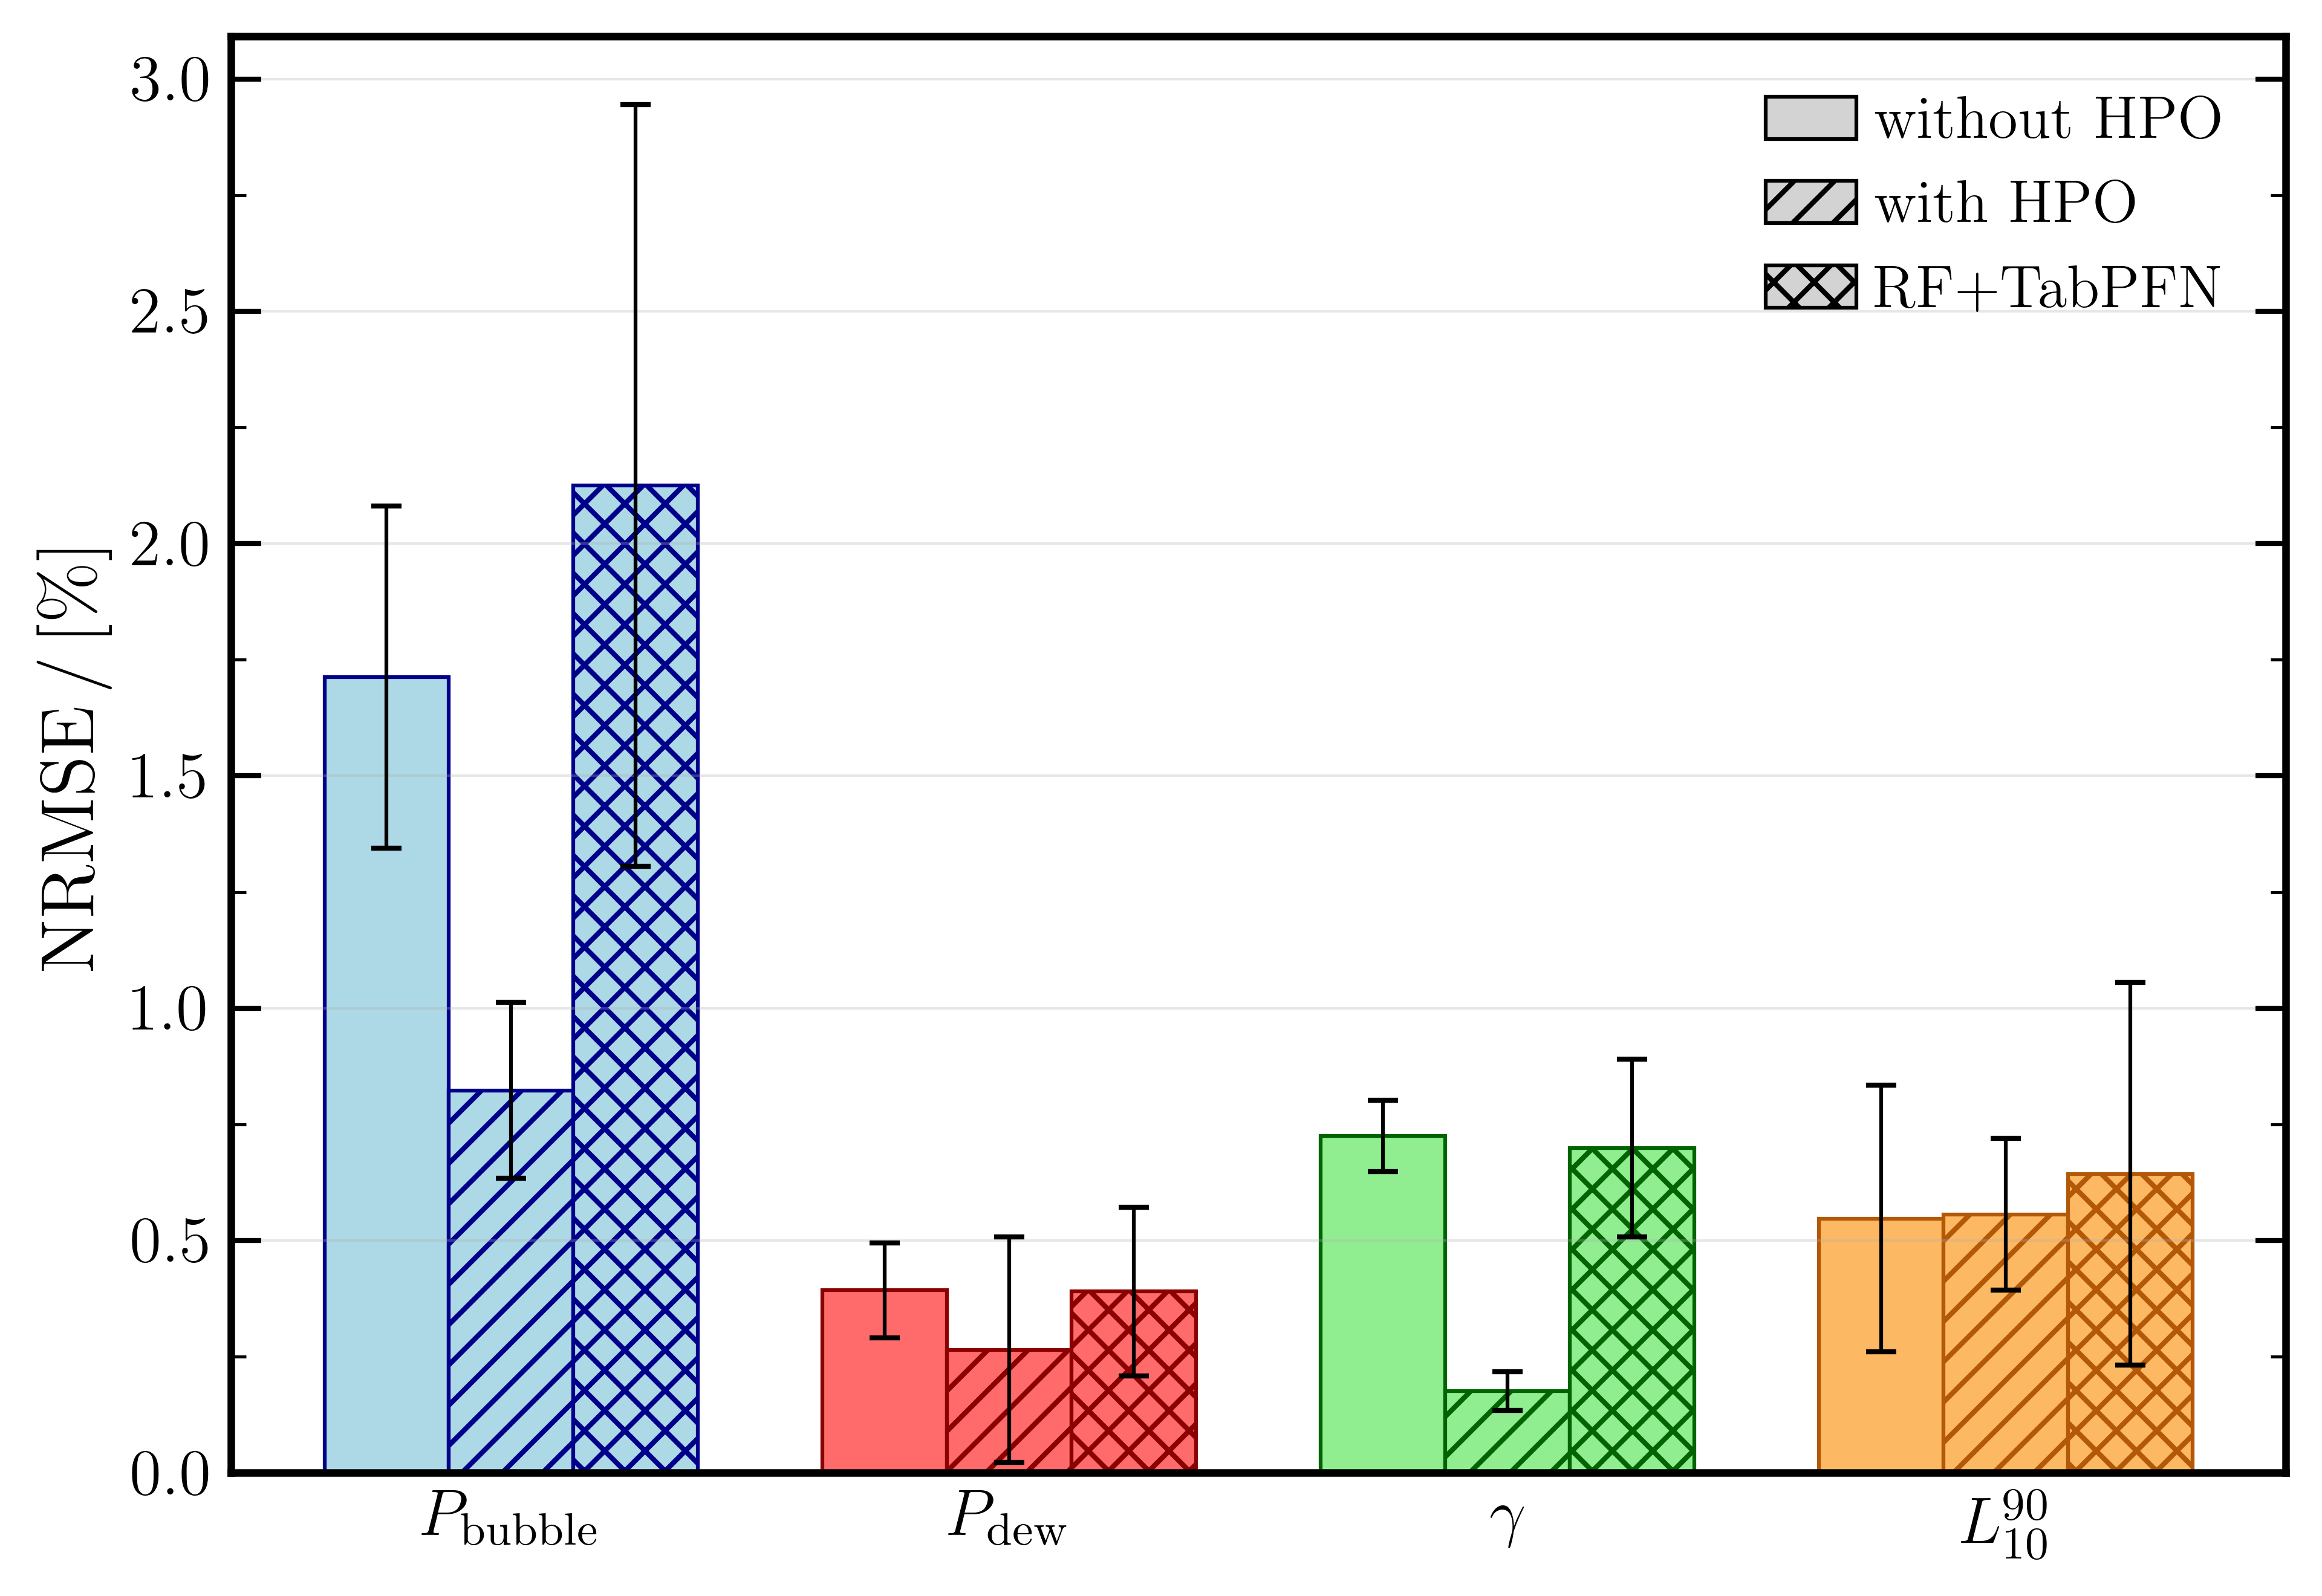

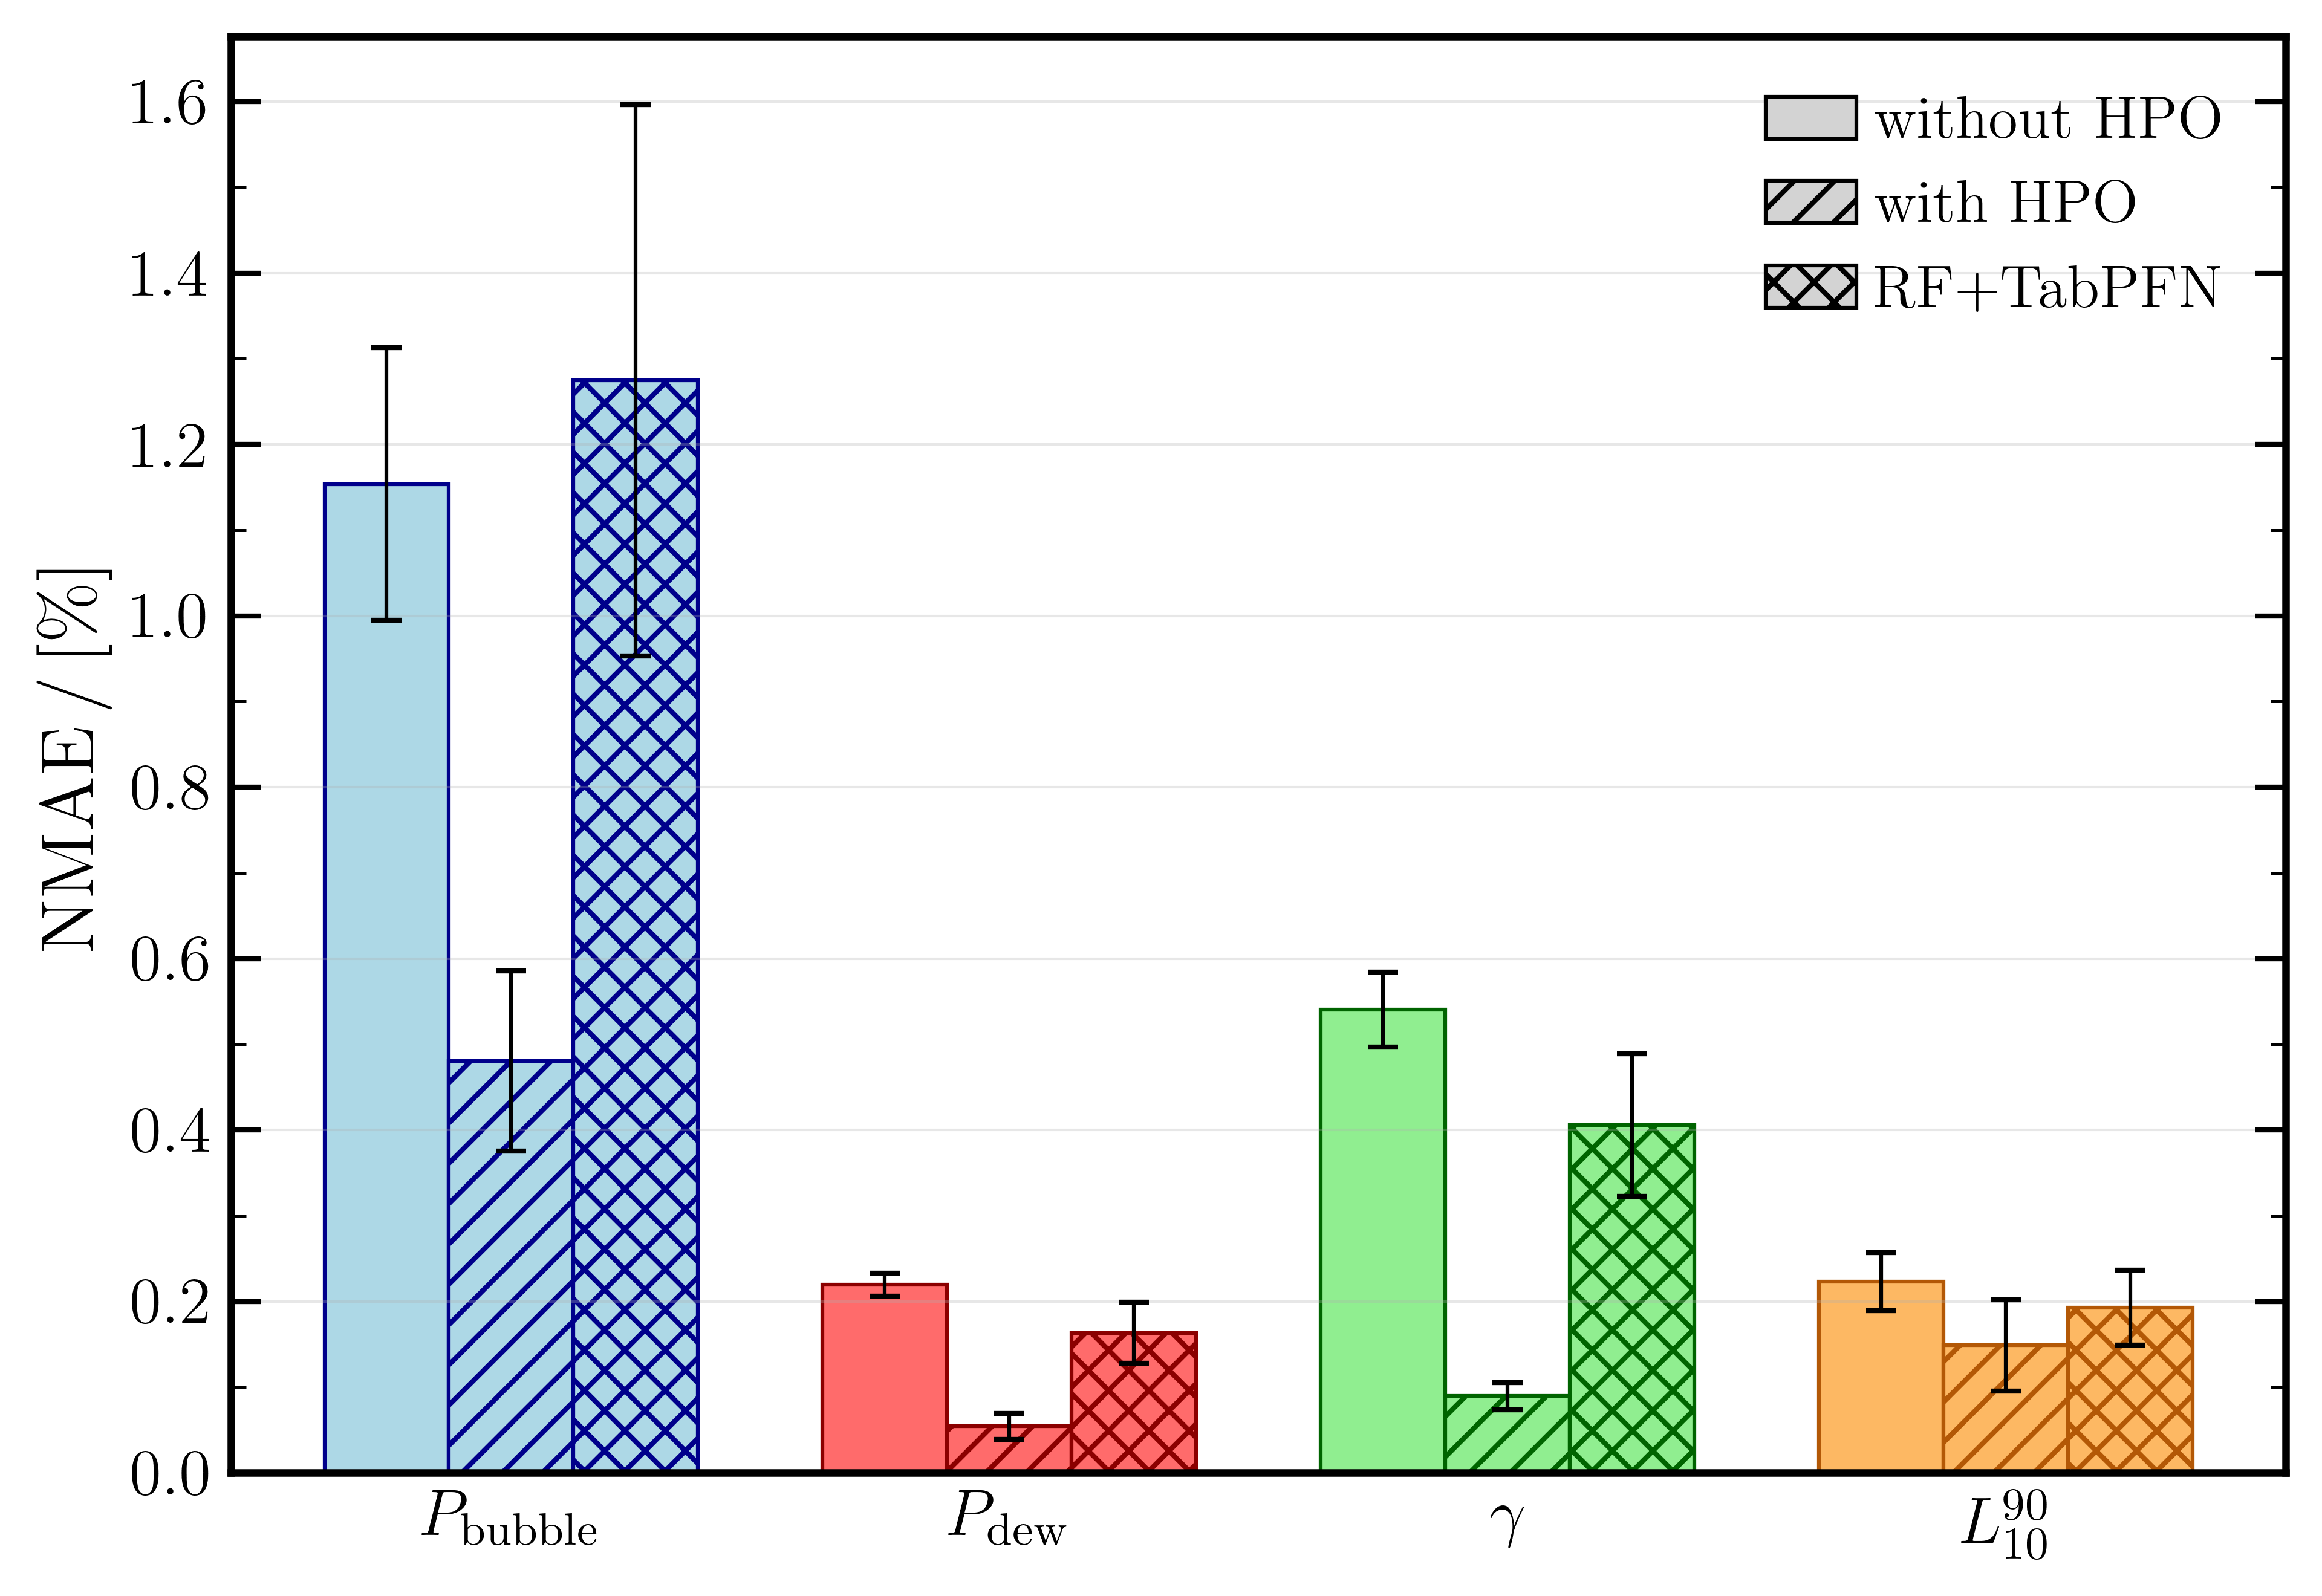

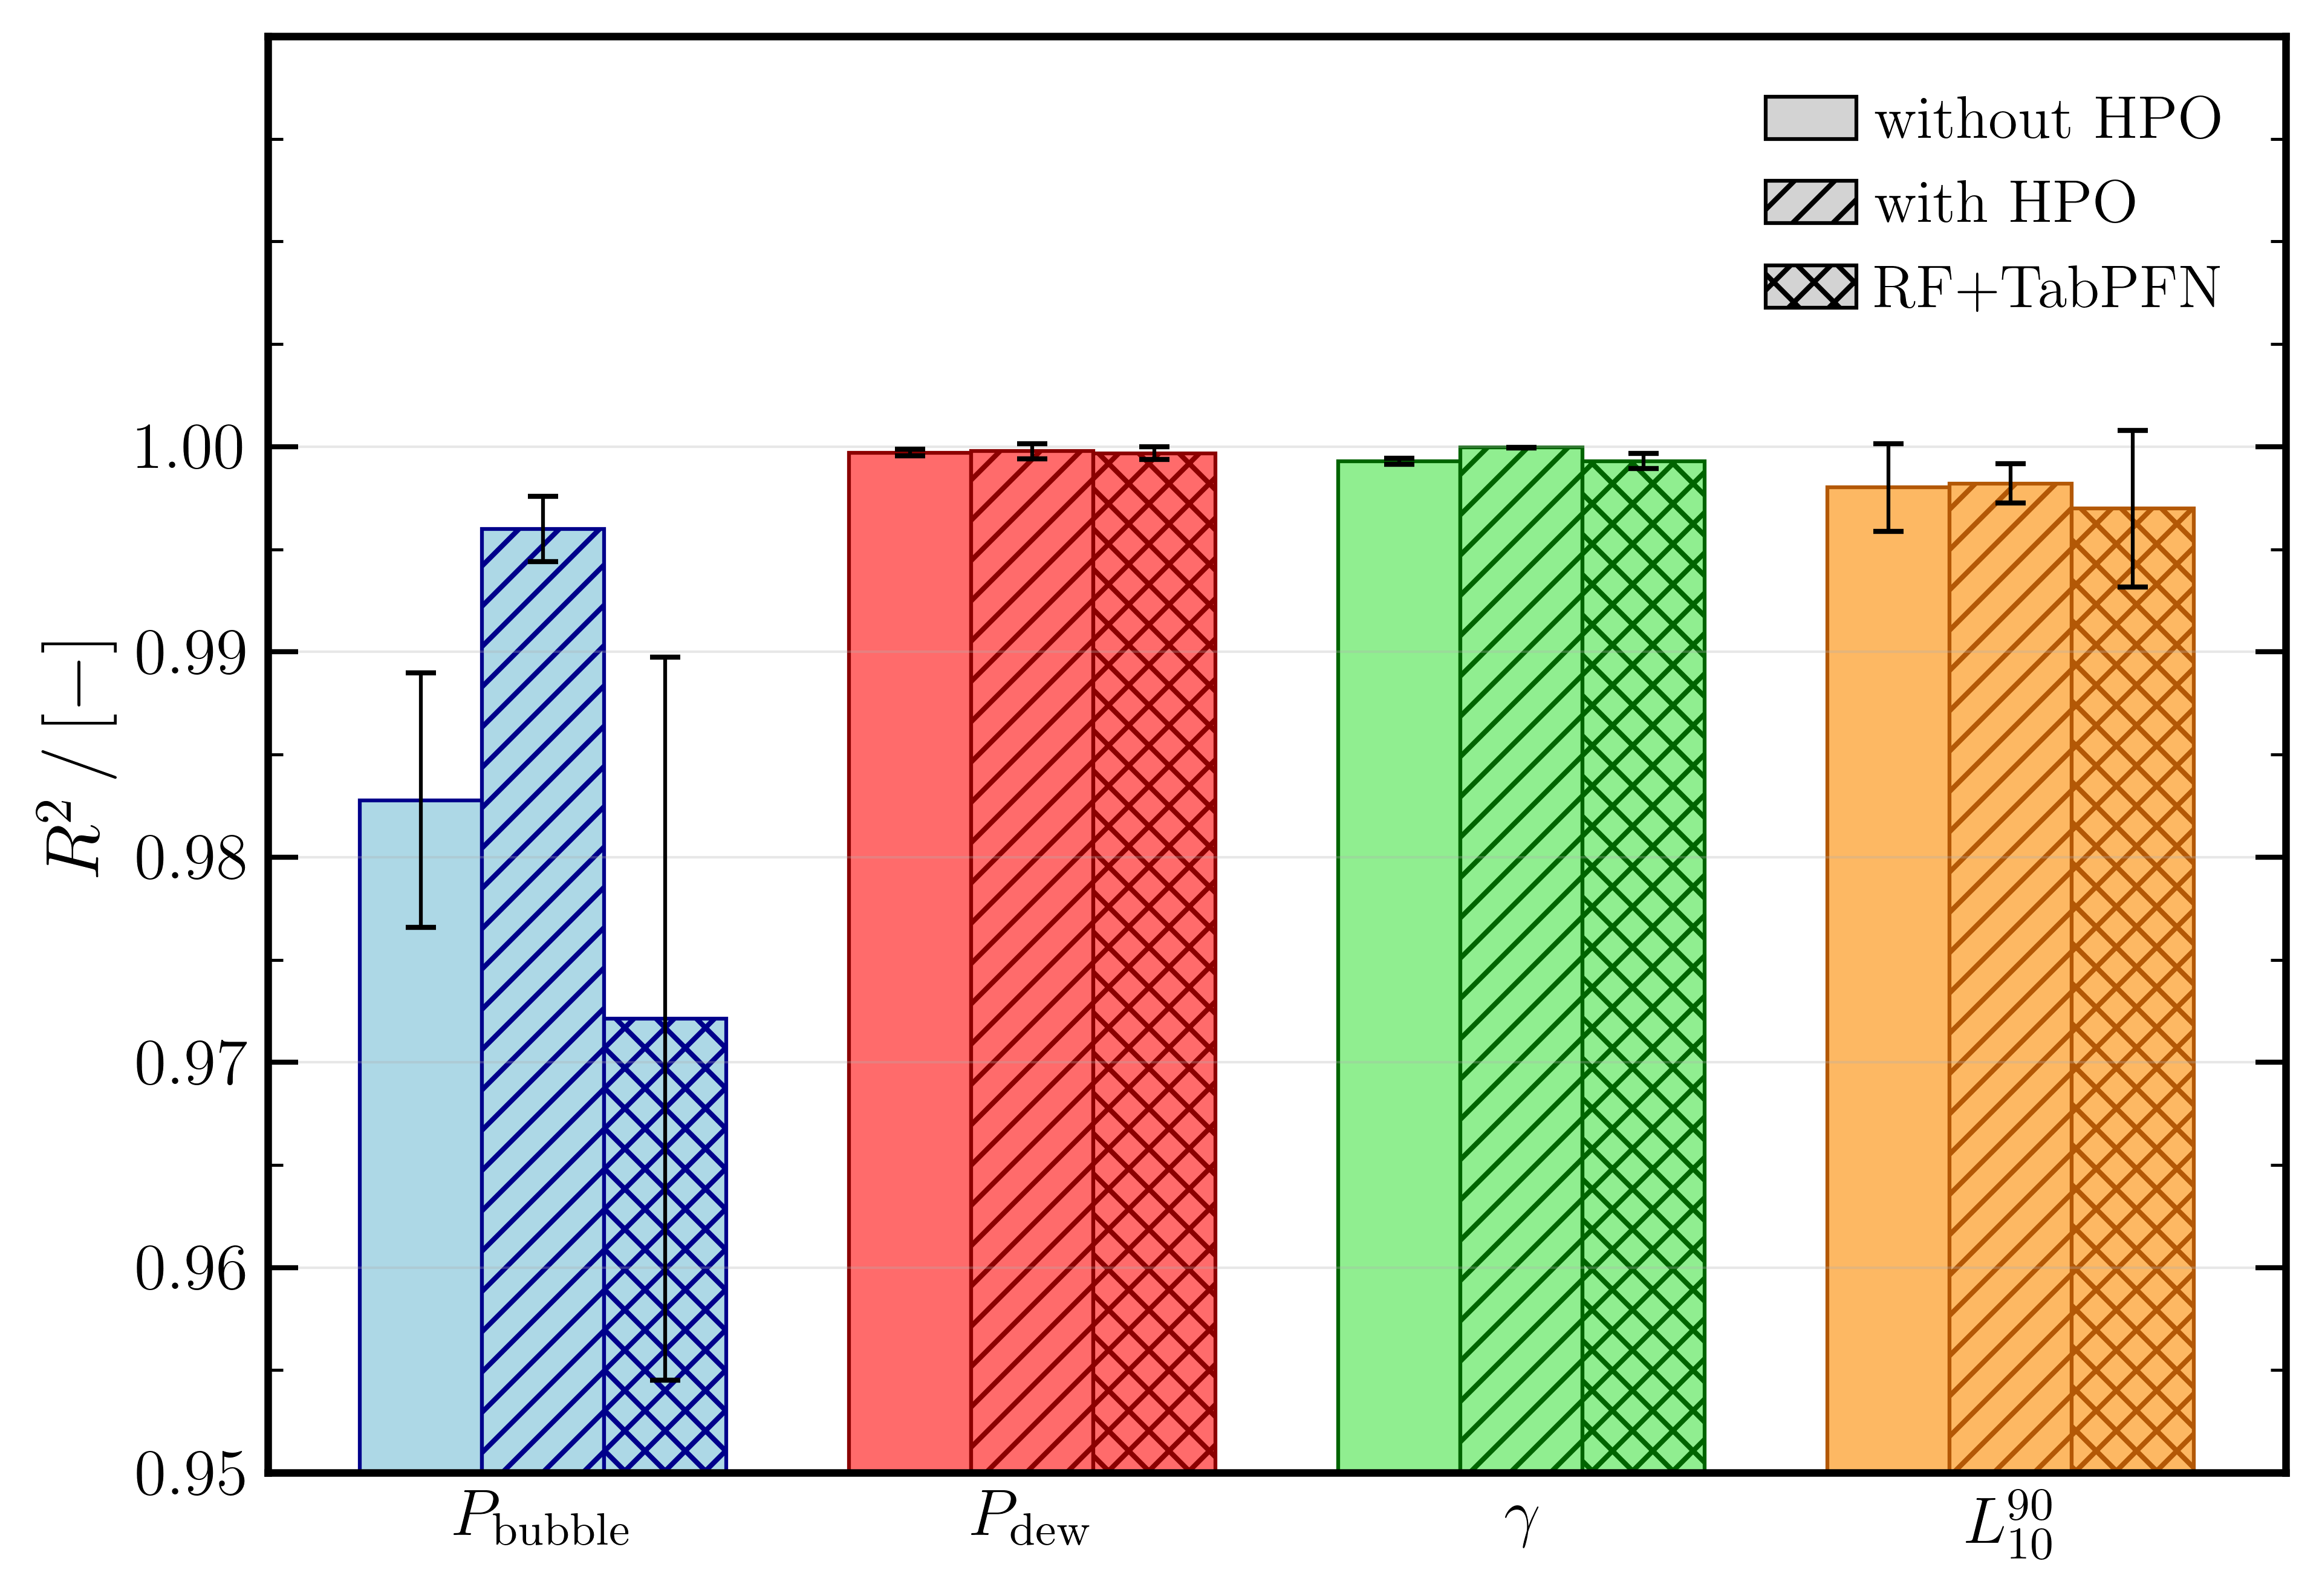

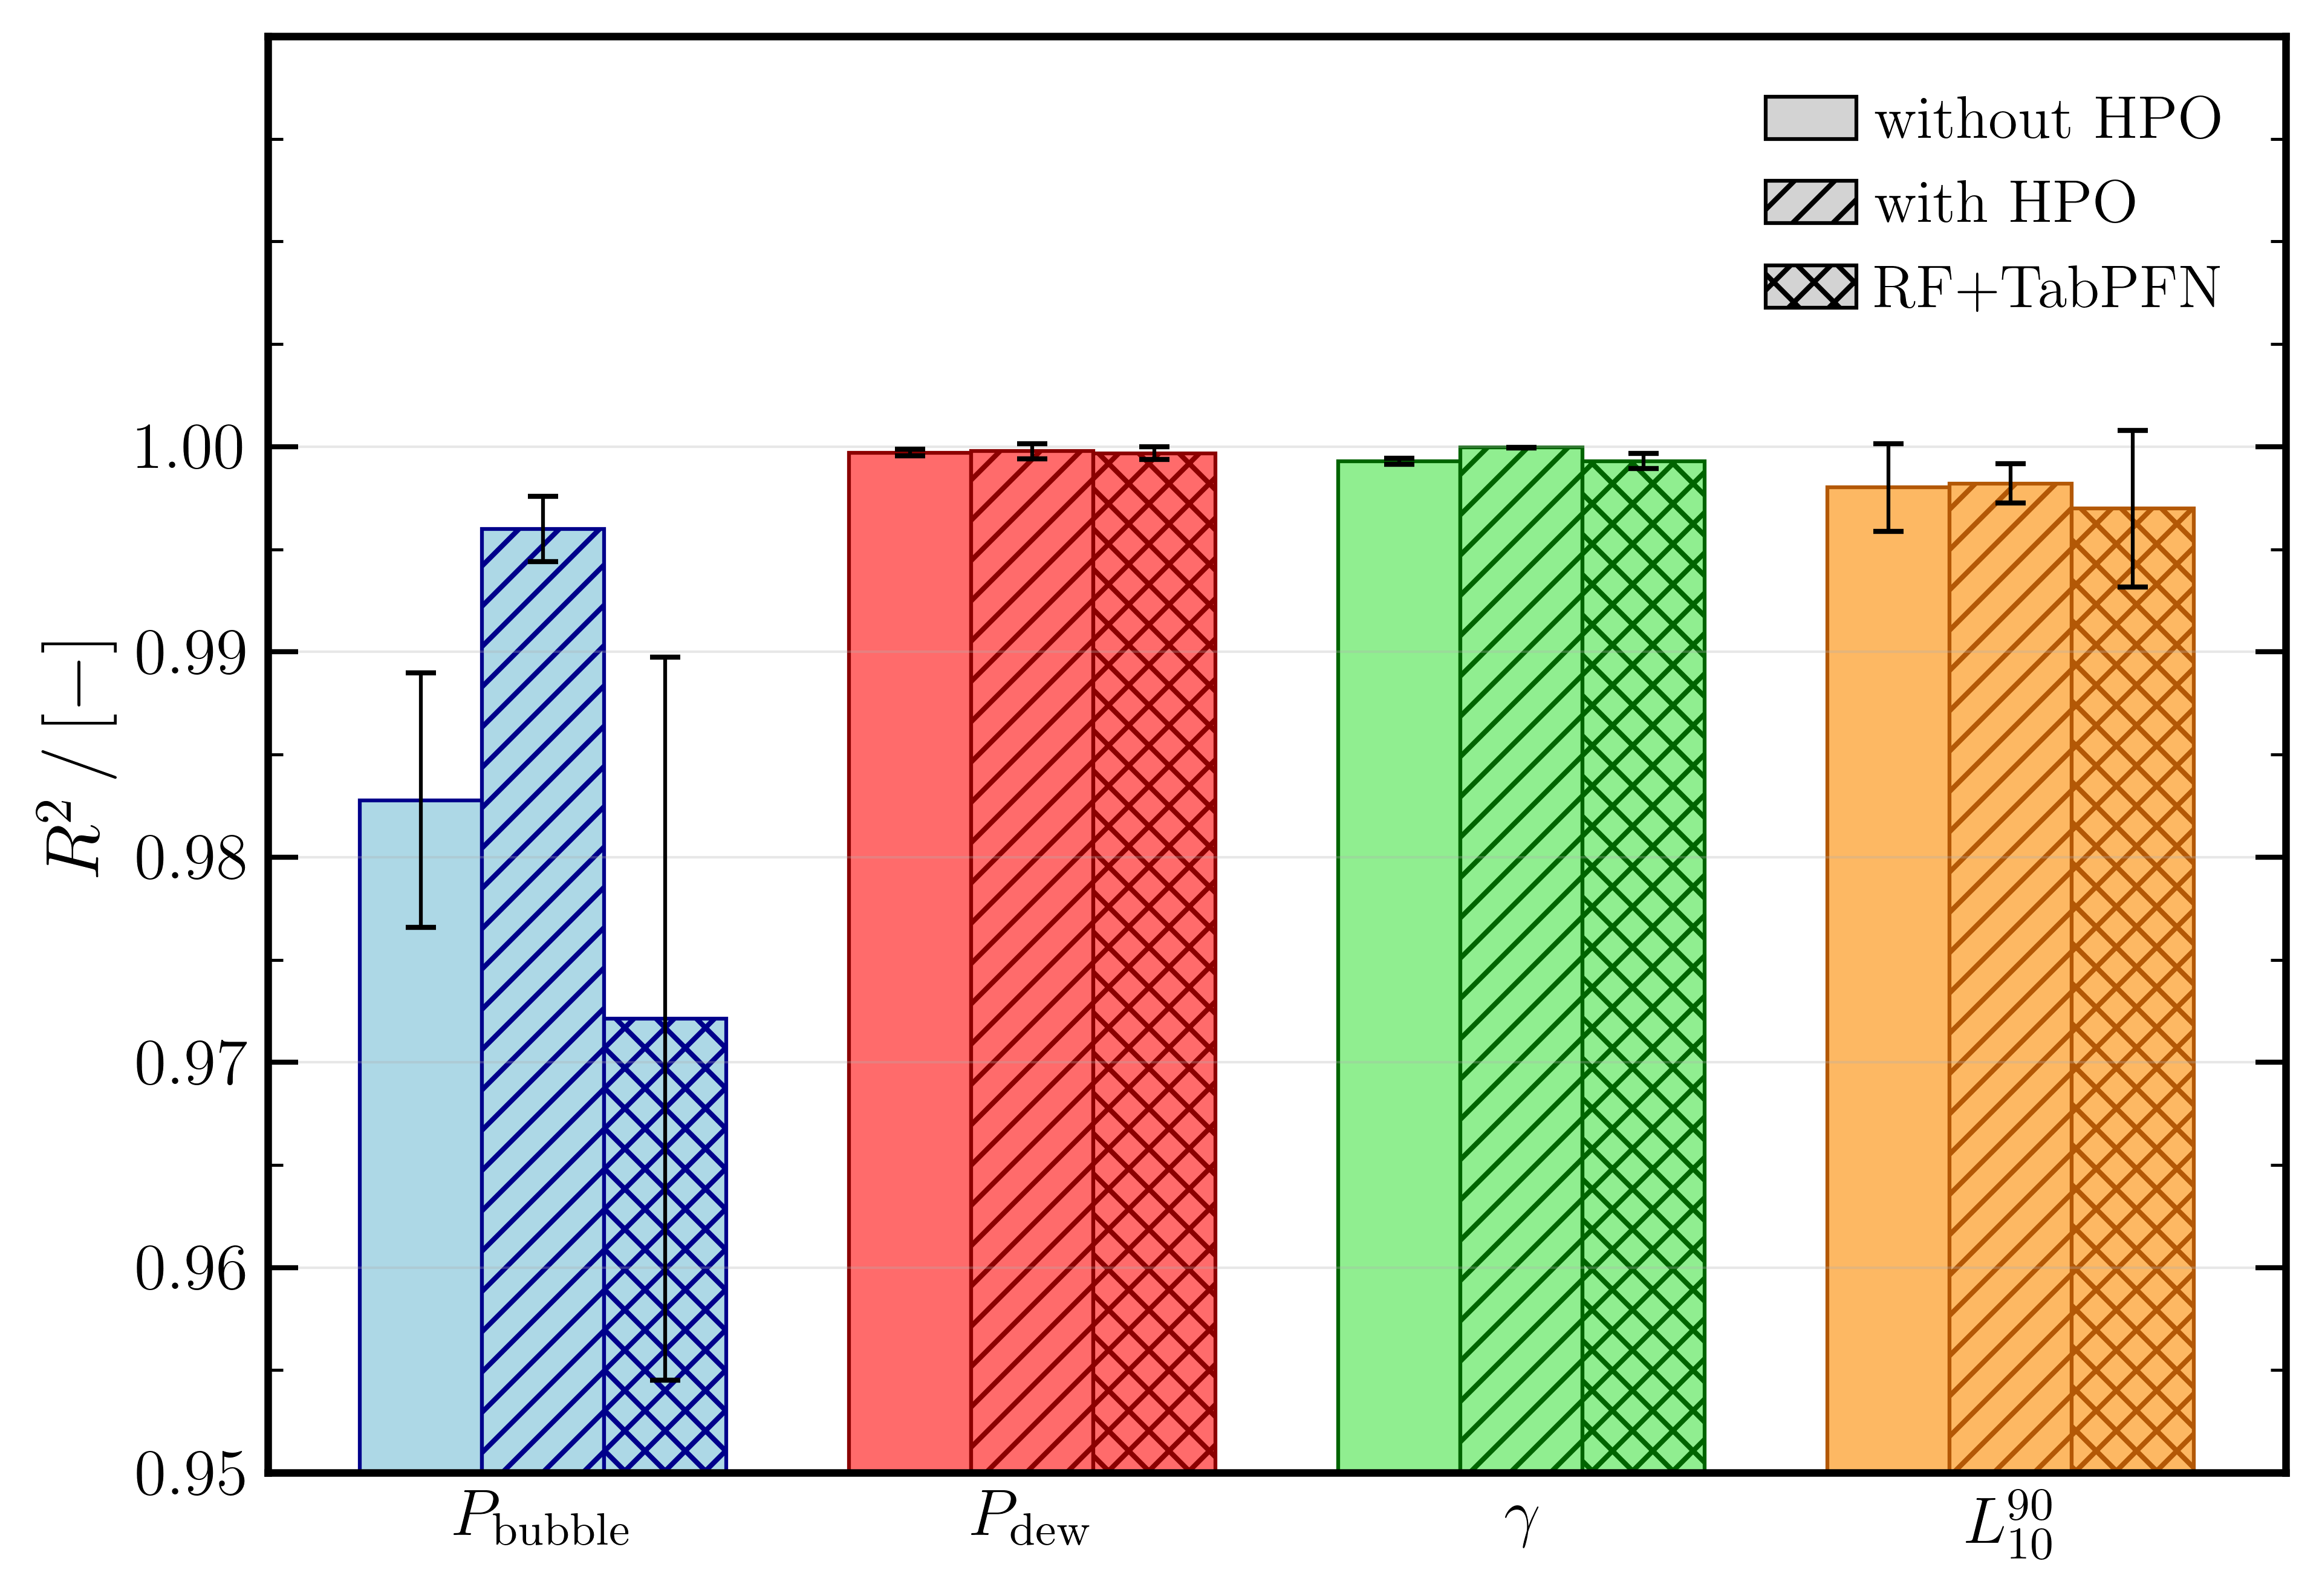

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import AutoMinorLocator

# ── thermoift plot settings ─────────────────────────────────────────────────
try:
    from thermoift.PLOT_SETTINGS import (
        plot_init, style_legend, save_plot,
        spine_width, tick_width, tick_length,
        minor_tick_width, minor_tick_length, tick_labelsize,
        symbol_map,
    )
    _ps_ok = True
except Exception as _te:
    display(Markdown(f"thermoift.PLOT_SETTINGS not available: `{_te}` — using plain matplotlib."))
    _ps_ok = False
    symbol_map = {}

# ── size overrides ──────────────────────────────────────────────────────────
_TICK_LABELSIZE  = 13
_LABEL_FONTSIZE  = 15
_TICK_LEN        = 6
_TICK_W          = 1.0
_MINOR_LEN       = 3
_MINOR_W         = 0.6
_LEGEND_FONTSIZE = 12

# derive x-tick labels from thermoift symbol_map; fall back to plain string
_TICK_LABELS = {
    prop: (
        r"$" + symbol_map[prop.lower()] + r"$"
        if prop.lower() in symbol_map and not symbol_map[prop.lower()].startswith("$")
        else symbol_map.get(prop.lower(), prop)
    )
    for prop in PROPERTIES
}


def _make_fig(w=6.5, h=4.5):
    if _ps_ok:
        return plot_init(w=w, h=h)
    fig, ax = plt.subplots(figsize=(w, h))
    return fig, ax


def plot_cv_bar(metric, err_metric, ylabel, filename, ylim=None, scale=1.0, yticks=None):
    width   = 0.25
    x       = list(range(len(PROPERTIES)))
    fig, ax = _make_fig()

    # y-axis: sized ticks on all four sides
    ax.tick_params(axis="y", which="major", direction="in",
                   length=_TICK_LEN, width=_TICK_W, labelsize=_TICK_LABELSIZE,
                   left=True, right=True)
    ax.tick_params(axis="y", which="minor", direction="in",
                   length=_MINOR_LEN, width=_MINOR_W,
                   left=True, right=True)
    # x-axis: labels only, no tick marks
    ax.tick_params(axis="x", which="both", length=0, labelsize=_TICK_LABELSIZE)

    for i, method in enumerate(METHODS):
        for j, prop in enumerate(PROPERTIES):
            val  = next(r[metric]     for r in rows if r["property"] == prop and r["method"] == method) * scale
            err  = next(r[err_metric] for r in rows if r["property"] == prop and r["method"] == method) * scale
            ckey = PROP_COLOR_KEY[prop]
            fc   = TARGET_COLORS[ckey]["facecolor"]
            ec   = TARGET_COLORS[ckey]["edgecolor"]
            pos  = x[j] + (i - 1) * width
            ax.bar(
                pos, val, width,
                yerr=err, capsize=3,
                ecolor="black", error_kw=dict(linewidth=0.75),
                facecolor=fc, edgecolor=ec, linewidth=0.75,
                hatch=HATCH_PATTERNS[method],
            )

    handles = [
        mpatches.Patch(
            facecolor="lightgrey", edgecolor="black",
            linewidth=0.75, hatch=HATCH_PATTERNS[m],
            label=METHOD_DISPLAY[m],
        )
        for m in METHODS
    ]

    ax.set_ylabel(ylabel, fontsize=_LABEL_FONTSIZE)
    ax.set_xticks(x)
    ax.set_xticklabels([_TICK_LABELS[p] for p in PROPERTIES], fontsize=_TICK_LABELSIZE)
    if yticks is not None:
        ax.set_yticks(yticks)
    ax.yaxis.set_minor_locator(AutoMinorLocator(2))  # 1 minor tick between majors
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.grid(axis="y", alpha=0.3, linewidth=0.5)

    if _ps_ok:
        style_legend(ax, handles=handles, loc="best", frame=False, fontsize=_LEGEND_FONTSIZE)
        save_plot(fig, filename, folder=str(OUT))
    else:
        ax.legend(handles=handles, loc="best", frameon=False, fontsize=_LEGEND_FONTSIZE)
        for ext in ("png", "pdf"):
            fig.savefig(str(OUT / f"{filename}.{ext}"), dpi=300, bbox_inches="tight")

    fig.tight_layout()
    plt.show()
    return fig


plot_cv_bar(
    "cv_nrmse_mean", "cv_nrmse_std",
    r"$\mathrm{NRMSE} \, / \, [\%]$",
    "comparisonCV_NRMSE",
    scale=100,
)
plot_cv_bar(
    "cv_nmae_mean", "cv_nmae_std",
    r"$\mathrm{NMAE} \, / \, [\%]$",
    "comparisonCV_NMAE",
    scale=100,
)
plot_cv_bar(
    "cv_r2_mean", "cv_r2_std",
    r"$R^2 \, / \, [-]$",
    "comparisonCV_R2",
    ylim=(0.95, 1.02),
    yticks=np.arange(0.95, 1.001, 0.01),
)
